# Random Forest

In [88]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',200)
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [10]:
# Loading dataset
df=pd.read_excel('C:/Data Science/Assignments_Files/Random Forest/glass.xlsx',sheet_name='glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### 1. Exploratory Data Analysis (EDA)


In [13]:
# Checking shape of the dataset
df.shape

(214, 10)

In [15]:
# Checking for column and there datatypes
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

In [17]:
# Checking for structural info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [19]:
# Understanding Statistical Info
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [23]:
# Checking for duplicates
df[df.duplicated()]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [27]:
# Removing duplicates
df.drop_duplicates(inplace=True)

In [29]:
# Checking for Null values
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

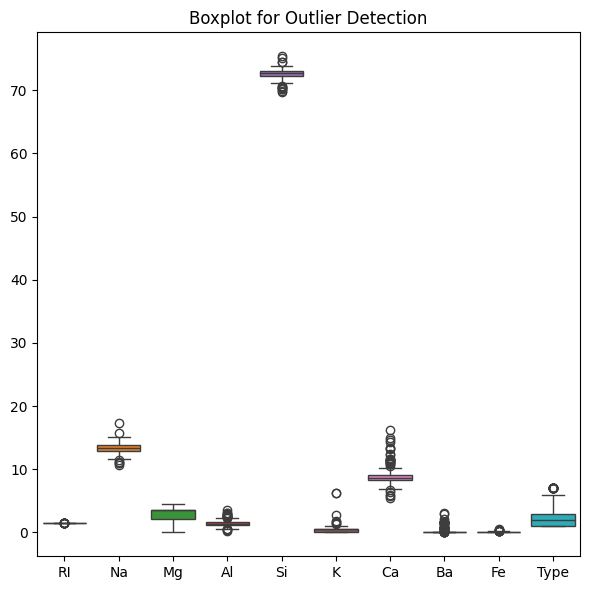

In [35]:
# Checking for outliers using boxplot
plt.figure(figsize=(6,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

### 2. Data Visualization

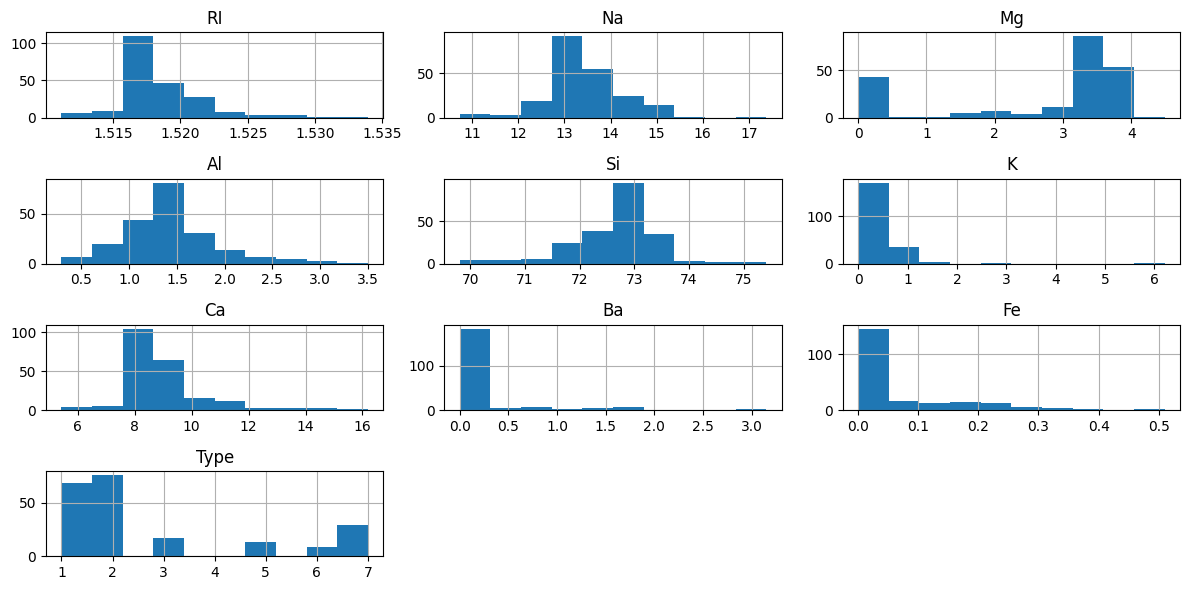

In [38]:
# Histograms
df.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

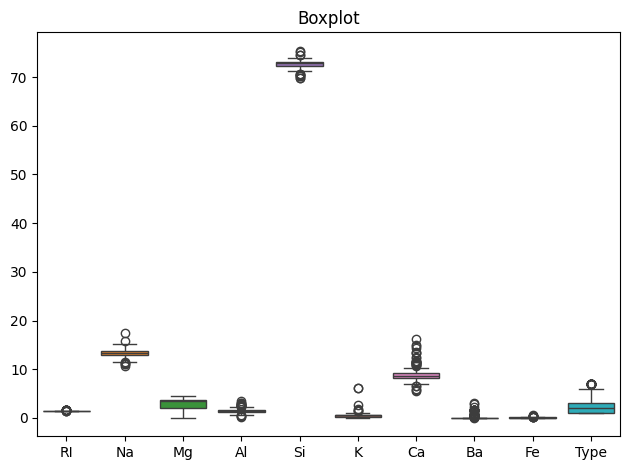

In [40]:
# Boxplot
sns.boxplot(data=df)
plt.title("Boxplot")
plt.tight_layout()
plt.show()

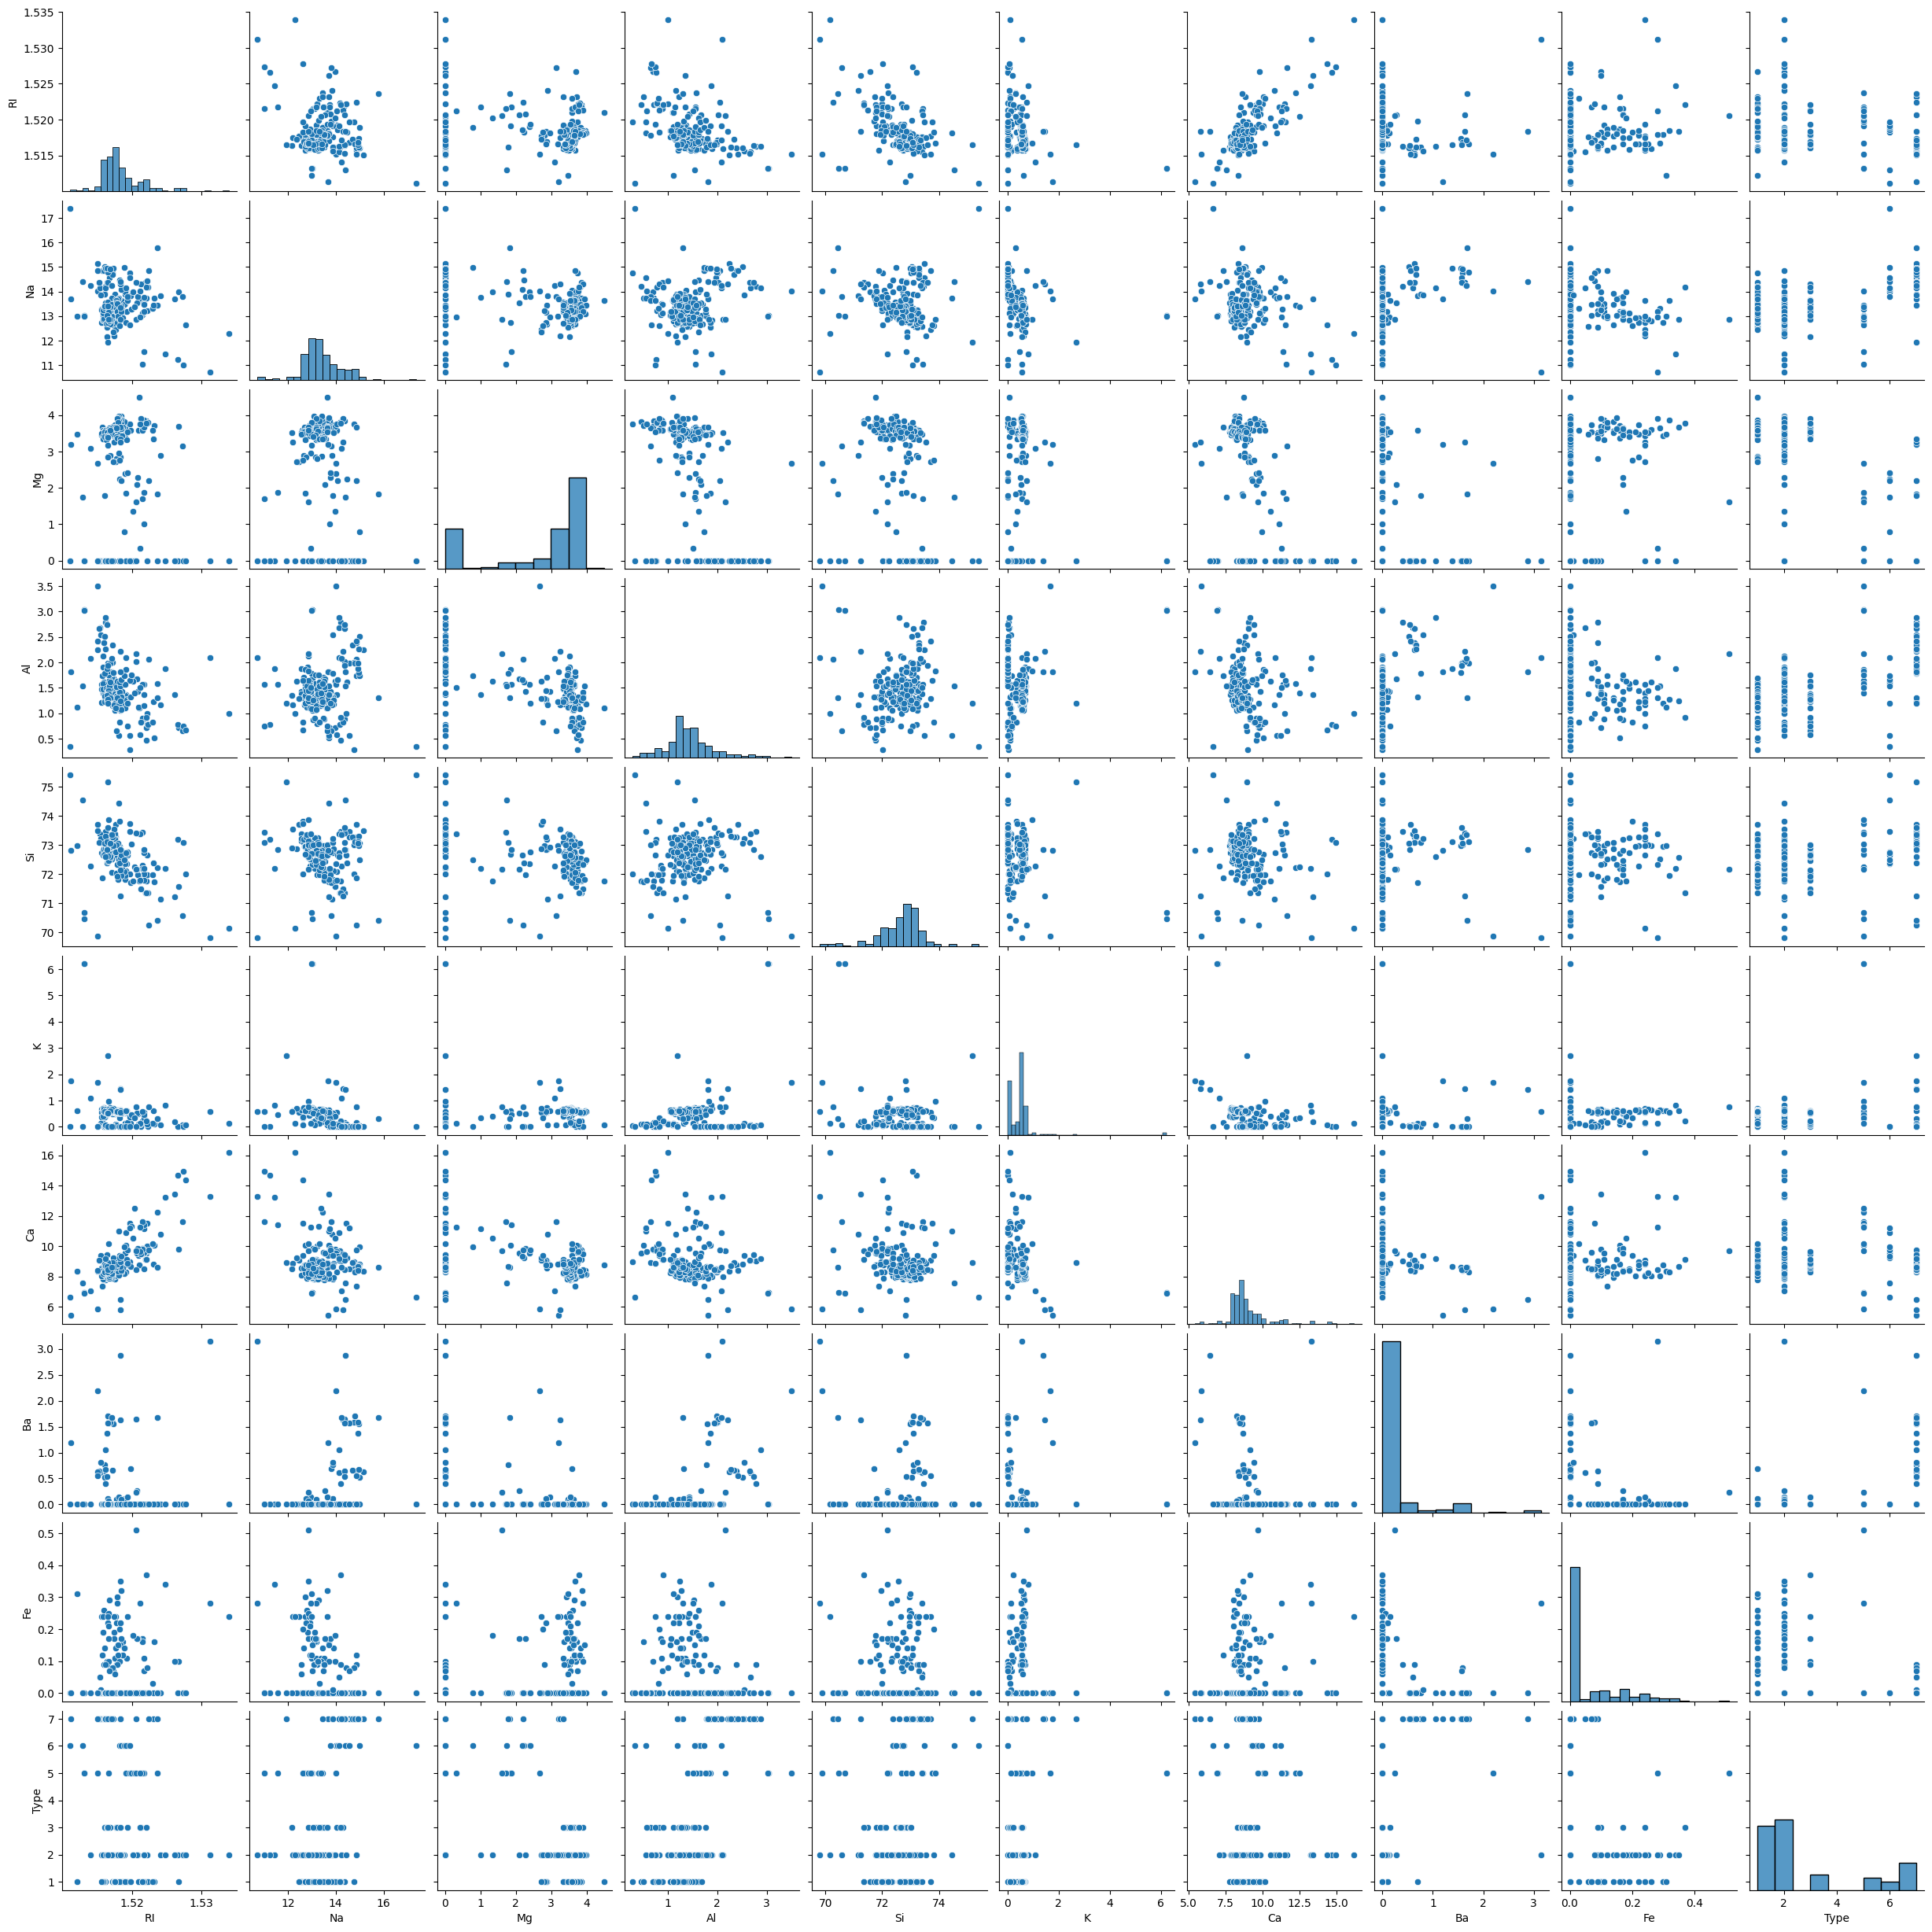

In [48]:
# Pairplot
sns.pairplot(data=df)
plt.show()

### Analysis on distributions and patterns
The Glass dataset is imbalanced, with most samples in classes 1 and 2. Features like RI, Na, Si, and Ca are roughly normally distributed, while Al is slightly skewed. K, Ba, and Fe are highly skewed with many near-zero values and some outliers. Mg shows a distinct pattern that may help in classification. Although outliers are present, Random Forest can handle them well, so minimal preprocessing is needed.

### 3: Data Preprocessing


In [52]:
# Checking and Handling missing values
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

No null values

In [54]:
# Encoding Categorical Datatypes
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

Since all are numerical → No encoding needed

In [62]:
# Feature ScalingX = df.drop('Type', axis=1)
X = df.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling applied")

Feature scaling applied


In [66]:
# Handling Imbalanced Data
X = df.drop('Type', axis=1)
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### 4: Random Forest Model Implementation


In [73]:
# Implement Random Forest
# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [75]:
# Predictions
y_pred = rf_model.predict(X_test)

In [81]:
# Model Evaluation
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision, Recall, F1 (macro for multiclass)
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8604651162790697
Precision: 0.8428571428571429
Recall: 0.8436507936507937
F1 Score: 0.831800766283525

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.93      0.90        14
           2       0.86      0.80      0.83        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.86        43
   macro avg       0.84      0.84      0.83        43
weighted avg       0.87      0.86      0.86        43



### 5: Bagging and Boosting Methods


In [86]:
# Bagging model
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# Train
bag_model.fit(X_train, y_train)

# Predict
y_pred_bag = bag_model.predict(X_test)

In [90]:
# Boosting model
boost_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# Train
boost_model.fit(X_train, y_train)

# Predict
y_pred_boost = boost_model.predict(X_test)

In [92]:
# Evaluate Both Models
# Bagging results
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nBagging Report:\n", classification_report(y_test, y_pred_bag))

# Boosting results
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print("\nBoosting Report:\n", classification_report(y_test, y_pred_boost))

Bagging Accuracy: 0.7906976744186046

Bagging Report:
               precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.79      0.81      0.79        43
weighted avg       0.80      0.79      0.79        43

Boosting Accuracy: 0.5348837209302325

Boosting Report:
               precision    recall  f1-score   support

           1       0.55      0.86      0.67        14
           2       0.43      0.40      0.41        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         2
           7       1

In [94]:
# Compare with Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Random Forest Accuracy: 0.8604651162790697
Bagging Accuracy: 0.7906976744186046
Boosting Accuracy: 0.5348837209302325


### Additional Notes

### Q1. Explain Bagging and Boosting methods. How are they different from each other?

**Answer:**  
Bagging (Bootstrap Aggregating) is an ensemble learning technique where multiple models are trained independently on different random subsets of the dataset, and their predictions are combined using voting or averaging. It helps reduce variance and improves stability. Random Forest is a common example of bagging.

Boosting is an ensemble method where models are trained sequentially, and each new model focuses on correcting the errors of the previous ones by giving more importance to misclassified data. It helps reduce bias and improves accuracy. AdaBoost is a popular boosting algorithm.

The main difference is that Bagging trains models independently, while Boosting trains models sequentially. Bagging reduces variance, whereas Boosting reduces bias. Also, Bagging treats all data equally, while Boosting focuses more on difficult or misclassified samples.

### Q2. Explain how to handle imbalance in the data.

**Answer:**  
Imbalanced data occurs when some classes have significantly more samples than others, which can lead to biased predictions. It can be handled using techniques like oversampling, undersampling, and class weighting. Oversampling methods such as SMOTE increase the number of samples in the minority class, while undersampling reduces the majority class samples. Stratified sampling can be used during train-test splitting to maintain class distribution. Additionally, using evaluation metrics like precision, recall, and F1-score instead of accuracy helps in better assessing model performance on imbalanced data.